# Sensitivity of a counting experiment

## Objectives

* **Estimate the sensitivity of the counting experiment**

* Given a number of background events in the RoI, what is the most probable limit that we set on $\mathcal{T}_{1/2}^{\beta\beta0\nu}$ in the case of no signal?

## Analysis

#### Importing modules

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

import scipy.constants as constants
import scipy.stats     as stats
import scipy.optimize  as optimize

import warnings
warnings.filterwarnings('ignore')

In [3]:
# REMEMBER TO ADD Your Fanal FOLDER TO PYTHONPATH
import os
import sys
rootpath = os.getcwd()[:-15]
print('add path to PYTHONPATH : ', rootpath)
sys.path.insert(0, os.path.abspath(rootpath))

add path to PYTHONPATH :  /Users/hernando/work/docencia/master/Fisica_Particulas/USC-Fanal-v2/


In [4]:
import core.pltext  as pltext   # extensions for plotting histograms
import core.hfit    as hfit     # extension to fit histograms
import core.efit    as efit     # Fit Utilites - Includes Extend Likelihood Fit with composite PDFs
import core.confint as confint  # Confidence Intervals 
import core.utils   as ut       # generic utilities
import ana.fanal    as fn       # analysis functions specific to fanal
import     collpars as collpars # collaboration specific parameters
pltext.style()

### The half-life relation 

The relation between $\mathcal{T}_{1/2}^{\beta\beta0\nu}$ and the estimated number of signal events $n^{\beta\beta}_{RoI}$ in the RoI is:

$$
\mathcal{T}_{1/2}^{\beta\beta0\nu} = \frac{\delta \, \epsilon^{\beta\beta}_{RoI} \, M \, t }{n^{\beta\beta}_{RoI}} \frac{N_A \, \log(2)}{W}
$$

Where:

  * $\delta$ is the abundance of $^{136}\mathrm{Xe}$ among other $\mathrm{Xe}$ isotopes (in our experiment, 0.9)
  * $\epsilon^{\beta\beta}_{RoI}$ is the efficiency of selecting signal events in the RoI (as a fraction, computed using MC)
  * $M$ is the mass of the detector (kg)
  * $t$ is the exposure time (y)
  * $N_A$ is the Avogadro number
  * $W$ is the atomic mass (g/mol)

## Main parameters

In [5]:
collaboration = collpars.collaboration
sel_ntracks   = collpars.sel_ntracks
sel_eblob2    = collpars.sel_eblob2
sel_erange    = collpars.sel_erange
sel_eroi      = collpars.sel_eroi

n_Bi_E        = collpars.n_Bi_E
n_Tl_E        = collpars.n_Tl_E
n_Bi_RoI      = collpars.n_Bi_RoI
n_Tl_RoI      = collpars.n_Tl_RoI


print('Collaboration             : {:s}'.format(collaboration))

Collaboration             : new_gamma


### Data

In [6]:
### data

# set the path to the data directory and filenames
dirpath = rootpath+'/data/'
filename = 'fanal_' + collaboration + '.h5'
print('Data path and filename : ', dirpath + filename)

# access the simulated data (DataFrames) for the different samples (Bi, Tl, bb) located in the data file
mcbi = pd.read_hdf(dirpath + filename, key = 'mc/bi214')
mctl = pd.read_hdf(dirpath + filename, key = 'mc/tl208')
mcbb = pd.read_hdf(dirpath + filename, key = 'mc/bb0nu')

# set the names of the samples
# set the names of the samples
mc_samples         = [mcbi, mctl, mcbb] # list of the mc DFs
sample_names       = ['Bi', 'Tl', 'bb']
sample_names_latex = [ r'$^{214}$Bi', r'$^{208}$Tl', r'$\beta\beta0\nu$',] # str names of the mc samples

for i, mc in enumerate(mc_samples):
    print('MC Sample {:s}, number of simulated events = {:d}'.format(sample_names[i], len(mc)))

Data path and filename :  /Users/hernando/work/docencia/master/Fisica_Particulas/USC-Fanal-v2//data/fanal_new_gamma.h5
MC Sample Bi, number of simulated events = 60184
MC Sample Tl, number of simulated events = 687297
MC Sample bb, number of simulated events = 47636


### Confidence Intervals

Frequentist intervals are usually computed using the Feldman–Cousins construction.
  
The following code constructs the confidence bands for a given number of *observed* events (on the *x* axis) and a range of *true signal events* (on the *y* axis).


**Exercise**:

  * Study how the CI changes depending on the number of observed events
  
  * Study what is the value of observed events that will give an observation and a discovery.

In [7]:
nbkg   = n_Bi_RoI + n_Tl_RoI
nbkg

81.684

In [8]:
nbkg   = n_Bi_RoI + n_Tl_RoI
n0     = int(nbkg)      # number of observed events (int)
cls    = (0.68, 0.90, 0.95)    # range of CL to show
factor = 1.5
nbins  = 100
nus    = np.linspace(0., factor * nbkg, 100) # range of number of signal events

# get the FC-CI functions for 68% and 95% CL
fcs    = [confint.get_fc_confinterval(nus, nbkg, cl = cl) for cl in cls]

for fc, cl in zip(fcs, cls):
    ci = fc(n0)
    print('FC Cover Interval, observed n = {:d}, at {:2.0f} % CL = ({:4.2f}, {:4.2f})'.format(n0, 100*cl, *ci))

FC Cover Interval, observed n = 81, at 68 % CL = (0.00, 7.43)
FC Cover Interval, observed n = 81, at 90 % CL = (0.00, 14.85)
FC Cover Interval, observed n = 81, at 95 % CL = (0.00, 18.56)


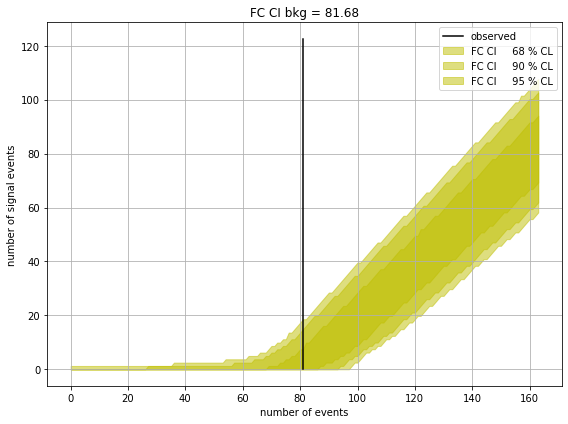

In [9]:
# plot the conficence band and the segment associated to an observation
pltext.canvas(1, 1, 6, 8)
ns   = np.arange(0, 2 * nbkg)
for fc, cl in zip(fcs, cls):    
    ys   = fc(ns)
    plt.fill_between(ns, *ys, alpha = 0.5, color = 'y', label = 'FC CI {:6.0f} % CL'.format(100*cl))
plt.plot(n0 * np.ones(len(nus)), nus, label = 'observed')
plt.legend(); plt.grid(which = 'both');
plt.title('FC CI bkg = {:4.2f}'.format(nbkg));
plt.xlabel('number of events'); plt.ylabel('number of signal events');
plt.tight_layout();

Translate the number of signal events into half-life time.

**Exercise**: Implement the *tau* function to return the half-life associated with *nbb* signal events in the selected RoI.

In [10]:
def tau(nbb):
    eff      = collpars.eff_bb_RoI
    exposure = collpars.exposure
    tau      = nbb/collpars.exposure # implement here the formula of the lifetime
    return tau

In [11]:
for fc, cl in zip(fcs, cls):
    ci   = fc(n0)
    taus = [tau(x) for x in ci]
    taus.reverse()
    print('FC Cover Interval, observed n = {:d}, at {:2.0f} % CL = ({:4.2e}, {:4.2e})'.format(n0, 100*cl, *taus))

FC Cover Interval, observed n = 81, at 68 % CL = (7.43e-03, 0.00e+00)
FC Cover Interval, observed n = 81, at 90 % CL = (1.49e-02, 0.00e+00)
FC Cover Interval, observed n = 81, at 95 % CL = (1.86e-02, 0.00e+00)


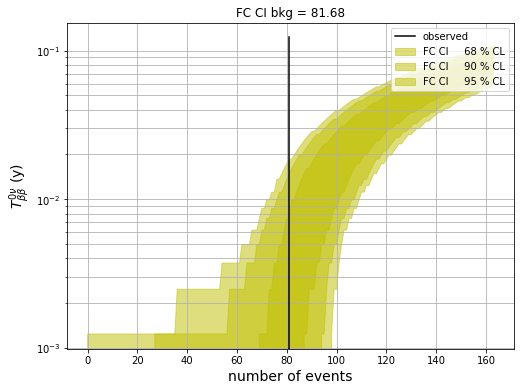

In [12]:
pltext.canvas(1, 1, 6, 8)
for fc, cl in zip(fcs, cls):    
    ys     = fc(ns)
    taus   = tau(ys)
    taus[taus == np.inf] = tau(nus[1])
    plt.fill_between(ns, *taus, 
                     alpha = 0.5, color = 'y', label = 'FC CI {:6.0f} % CL'.format(100*cl))
plt.plot(n0 * np.ones(len(nus)), tau(nus), label = 'observed')
plt.legend(); plt.grid(which = 'both');
plt.title('FC CI bkg = {:4.2f}'.format(nbkg));
plt.xlabel('number of events', fontsize = 14); plt.ylabel(r'$T^{0\nu}_{\beta\beta}$ (y)', fontsize = 14);
plt.yscale('log');
#plt.tight_layout();

### Compute the p-value of the null hypothesis


The p-value is the probability of obtaining an experiment with agreement with no-signal equal to or worse than the observation.

When the p-value of the null hypothesis is below 3 sigma, we claim evidence; when it is below 5 sigma, a discovery!

Note that we claim a discovery when the data does not agree with the background-only hypothesis.

In the case of a counting experiment, the distribution of the number of observed events under the no-signal hypothesis is a Poisson distribution with mean $n^{bkg}_{RoI}$, the number of background events in the RoI.

In [13]:
Z3    = 0.0027  # 3-sigma
Z5    = 2.87e-7 # 5-sigma
p0 = stats.poisson.sf(ns, nbkg) 

for z in (Z3, Z5):
    if (np.min(p0) < z):
        n1 = int(np.min(ns[p0<z]))
        print('p0-values < {:1.2e} if n > {:d}, Tbb < {:1.2e} y'.format(z, n1, tau(n1)))

p0-values < 2.70e-03 if n > 108, Tbb < 1.08e-01 y
p0-values < 2.87e-07 if n > 131, Tbb < 1.31e-01 y


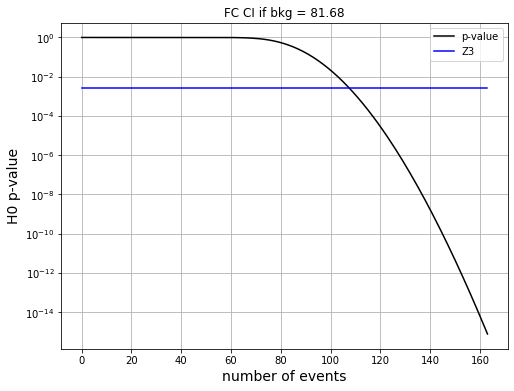

In [14]:
pltext.canvas(1, 1, 6, 8)
p0 = stats.poisson.sf(ns, nbkg) 
plt.plot(ns, p0, label = 'p-value')
plt.plot(ns, Z3 * np.ones(len(ns)), label = 'Z3')
plt.title('FC CI if bkg = {:4.2f}'.format(nbkg));
plt.xlabel('number of events', fontsize = 14); plt.ylabel(r'H0 p-value', fontsize = 14);
plt.yscale('log'); plt.grid(which = 'both'); plt.legend();